## Project: SVM
### Predict Online Shoppers' Intention To Make a Purchase (By: Archit Pandya)

**`Problem Statement:`** The objective of this project is to predict online shoppers' intention to make a purchase based on various features related to their browsing behaviour. The dataset comprises 12,330 sessions, each belonging to a different user, over a 1-year period. The features include both numerical and categorical attributes, providing insights into users' interactions with the website.

The dataset consists of feature vectors belonging to 12,330 sessions. The dataset was formed so that each session would belong to a different user in a 1-year period to avoid any tendency to a specific campaign, special day, user profile, or period.

**`You are suppose to do EDA,various feature transformations and apply the SVM model with hyperparameter tuning. Since it is imabalanced data, evaluation metric will be f1 score. The benchmark f1 score is 0.55`**

**Feature Description**
<br>`Administrative:` The number of pages of this type (administrative) visited by the user in that session.
<br>`Administrative Duration:` The total amount of time (in seconds) spent by the user on administrative pages during the session.
<br>`Informational:` The number of informational pages visited by the user in that session.
<br>`Informational Duration:` The total time spent by the user on informational pages.
<br>`Product Related:` The number of product-related pages visited by the user.
<br>`Product Related Duration:`  The total time spent by the user on product-related pages.
<br>`Bounce Rates:` The average bounce rate of the pages visited by the user. The bounce rate is the percentage of visitors who navigate away from the site after viewing only one page.
<br>`Exit Rates:` The average exit rate of the pages visited by the user. The exit rate is a metric that shows the percentage of exits from a page.
<br>`PageValues:` The average value of the pages visited by the user. This metric is often used as an indicator of how valuable a page is in terms of generating revenue.
<br>`SpecialDay:` This indicates the closeness of the site visiting time to a specific special day (e.g., Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with a transaction.
<br>`Month:` The month of the year in which the session occurred. 
<br>`OperatingSystems:` The operating system used by the user.
<br>`Browser:` The browser used by the user.
<br>`Region:` The region from which the user is accessing the website.
<br>`Traffic Type:` The type of traffic (e.g., direct, paid search, organic search, referral).
<br>`Visitor Type:` A categorization of users (e.g., Returning Visitor, New Visitor).
<br>`Weekend:` A Boolean indicating whether the session occurred on a weekend.

**Target**
<br>`Revenue:` A binary variable indicating whether the session ended in a transaction (purchase).

## Model Implementation

   - 1.[Imports and Read Data](#1)
       - Import Python libraries and load the data file to conduct data analysis
   - 2.[Data Understanding](#2)
       - Dataframe Shape
       - head and tail
       - Null or Missing Data
       - dtypes and information
   - 3.[Data Preparation](#3)
       - Convert columns into appropriate datatypes
       - Renaming Columns if any
       - Feature Creation
       - Check Duplicates
   - 4.[Feature Understanding (Univariable Analysis)](#4)
       - 4.a. Univariate Analysis (Categorical Features)
       - 4.b. Univariate Analysis (Numerical Features)
       - 4.c. Any potential Outliers
   - 5.[Feature Realtionships (Bivariate Analysis)](#5)
       - 5.a. Bivariate Analysis : Numerical - Numerical
       - 5.b. Bivariate Analysis : Categorical - Categorical
            - List of Hypothesis (2-Tailed Test)
       - 5.c. Bivariate Analysis : Continuous - Categorical
            - List of Hypothesis (2-Tailed Test)
   - 6.[Feature Realtionships (Multivariate Analysis)](#6)
       - 6.a. Pivot Table
   - 7.[Feature Engineering](#7)
       - 7.1 Handle Missing Values
       - 7.2 Feature Generation - Binning
       - 7.3 Identify and Remove Outlier
       - 7.4 Encoding (Label Encoding, One-Hot Encoding, Target Encoding)
   - 8.[Preprocess Data](#8)
       - 8.1 Prepare List for Categorical and Numerical Datatypes
       - 8.2 Decide Encoding Technique for Categorical Datatypes
       - 8.3 Perform 'Frequency Encoding' for Categorical Datatypes
       - 8.4 Decide Encoding Technique for Numerical Datatypes
       - 8.5 Decide Encoding Technique for Numerical Datatypes
       - 8.6 Perform 'Min Max Scaling' and Drop Columns
   - 9.[Build Mode](#9)
       - 9.1 Import Libraries
       - 9.2 Handle the Imbalance
       - 9.3 Instantiate the Classifier and Define Parameter Grid
       - 9.4 Perform GridSearchCV and Get 'Best_Estimator' and 'Best _Params'
       - 9.5 Compute Model Metrices
       - 9.6 List and Visualize the Model Performance

## 1. Import Libraries and Read and Data<a id='1'></a>

In [1]:
# Import necessary Python Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

print('Imported Libraries')

Imported Libraries


In [2]:
# Read 'credit_data' CSV file that is available from the 'data' directory from which this notebook is saved

online_shoppers_data_df = pd.read_csv('PAhiz_online shoppers intention.csv')
online_shoppers_data_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,10,416.583333,0.0,0.036667,0.000000,0.0,Dec,1,1,3,2,Returning_Visitor,0,0
1,0,0.000000,0,0.0,3,133.500000,0.0,0.088889,0.000000,0.0,Mar,1,2,1,8,Returning_Visitor,0,0
2,5,408.408333,2,47.5,54,1547.477273,0.0,0.017333,0.000000,0.0,Nov,2,2,3,2,Returning_Visitor,1,1
3,0,0.000000,0,0.0,19,686.583333,0.0,0.010526,0.000000,0.0,Dec,1,1,5,2,Returning_Visitor,1,0
4,0,0.000000,0,0.0,69,2734.818254,0.0,0.004353,49.392716,0.0,May,4,5,3,2,Returning_Visitor,0,1


## 2. Understand Dataframe<a id='2'></a>

In [3]:
# Find row and column counts of 'credit_data' dataframe

online_shoppers_data_df.shape

(12330, 18)

In [4]:
# Find any null values from 'online_shoppers_data'

online_shoppers_data_df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
# Feature Names, Datatypes, Total Rows, Missing for each feature

online_shoppers_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
# List column to typecast to 'category'

# num_cols_mnmx = ['Administrative_Duration','Informational_Duration','ProductRelated']

mnmx_cols     = ['Administrative_Duration','Informational_Duration','ProductRelated',\
                 'Administrative','Informational','ProductRelated_Duration','PageValues']

do_nothing    = ['BounceRates','ExitRates','SpecialDay','Weekend','Revenue']

cat_cols_ohe  = ['Browser','Region','TrafficType','OperatingSystems','Month','VisitorType']

xcols         = ['Administrative', 'Administrative_Duration', 'Informational',\
                'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration','BounceRates', \
                'ExitRates', 'PageValues', 'SpecialDay', 'Month','OperatingSystems', 'Browser', 'Region', \
                'TrafficType', 'VisitorType','Weekend']

all_cols      = online_shoppers_data_df.columns

In [7]:
online_shoppers_data_df[mnmx_cols].head()

,Administrative_Duration,Informational_Duration,ProductRelated,Administrative,Informational,ProductRelated_Duration,PageValues
0,0.000000,0.0,10,0,0,416.583333,0.000000
1,0.000000,0.0,3,0,0,133.500000,0.000000
2,408.408333,47.5,54,5,2,1547.477273,0.000000
3,0.000000,0.0,19,0,0,686.583333,0.000000
4,0.000000,0.0,69,0,0,2734.818254,49.392716


<Figure size 2000x400 with 0 Axes>

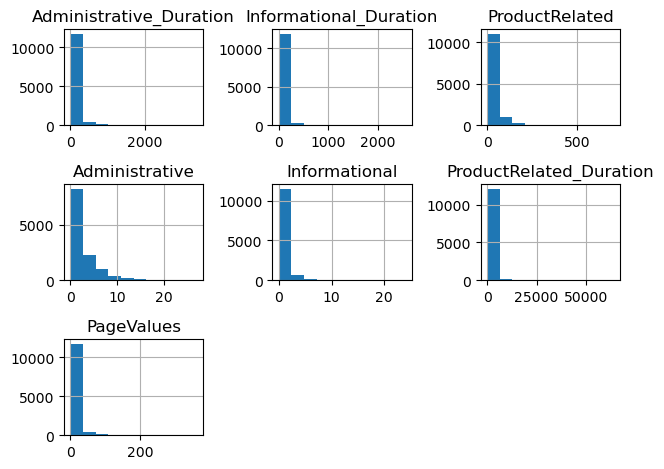

In [8]:
plt.figure(figsize=(20,4))
online_shoppers_data_df[mnmx_cols].hist();
plt.tight_layout()

In [9]:
online_shoppers_data_df[cat_cols_ohe].head()

,Browser,Region,TrafficType,OperatingSystems,Month,VisitorType
0,1,3,2,1,Dec,Returning_Visitor
1,2,1,8,1,Mar,Returning_Visitor
2,2,3,2,2,Nov,Returning_Visitor
3,1,5,2,1,Dec,Returning_Visitor
4,5,3,2,4,May,Returning_Visitor


In [10]:
online_shoppers_data_df[do_nothing].head()

,BounceRates,ExitRates,SpecialDay,Weekend,Revenue
0,0.0,0.036667,0.0,0,0
1,0.0,0.088889,0.0,0,0
2,0.0,0.017333,0.0,1,1
3,0.0,0.010526,0.0,1,0
4,0.0,0.004353,0.0,0,1


<Figure size 2000x400 with 0 Axes>

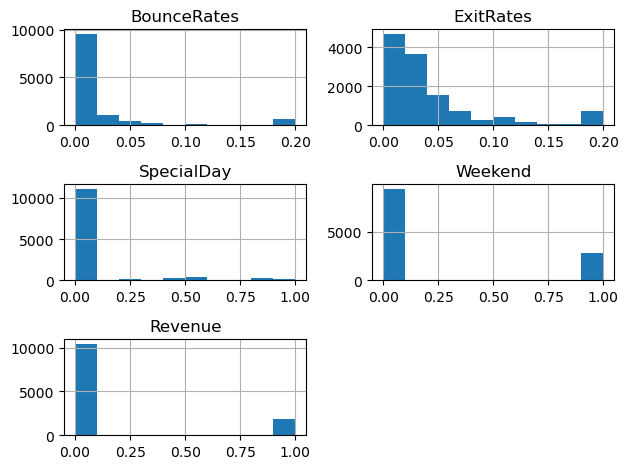

In [11]:
plt.figure(figsize=(20,4))
online_shoppers_data_df[do_nothing].hist();
plt.tight_layout()

## 3. Preprocess Data Using Function / Column Transformer and Pipeline<a id='3'></a>

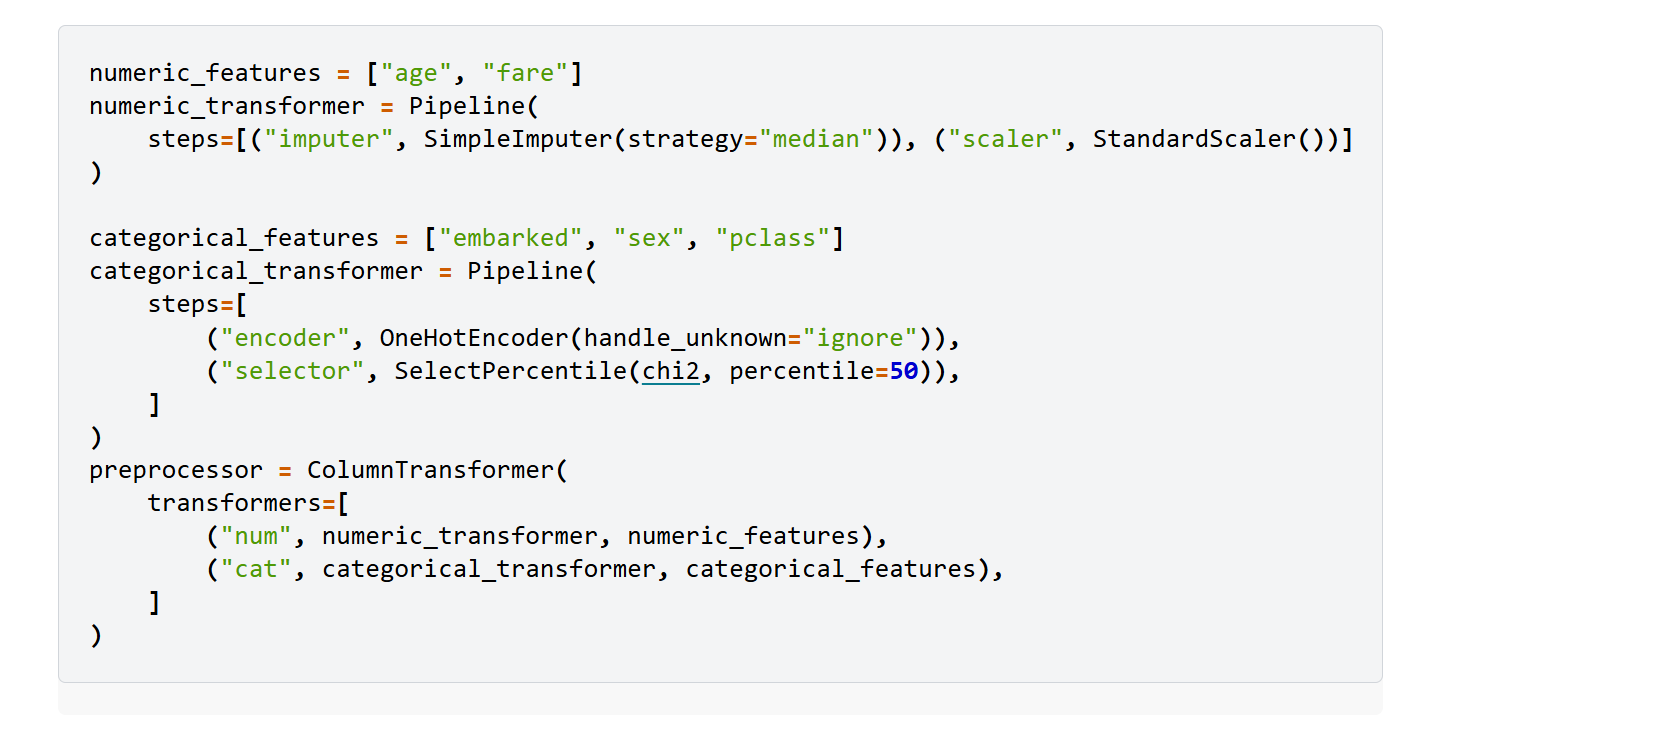
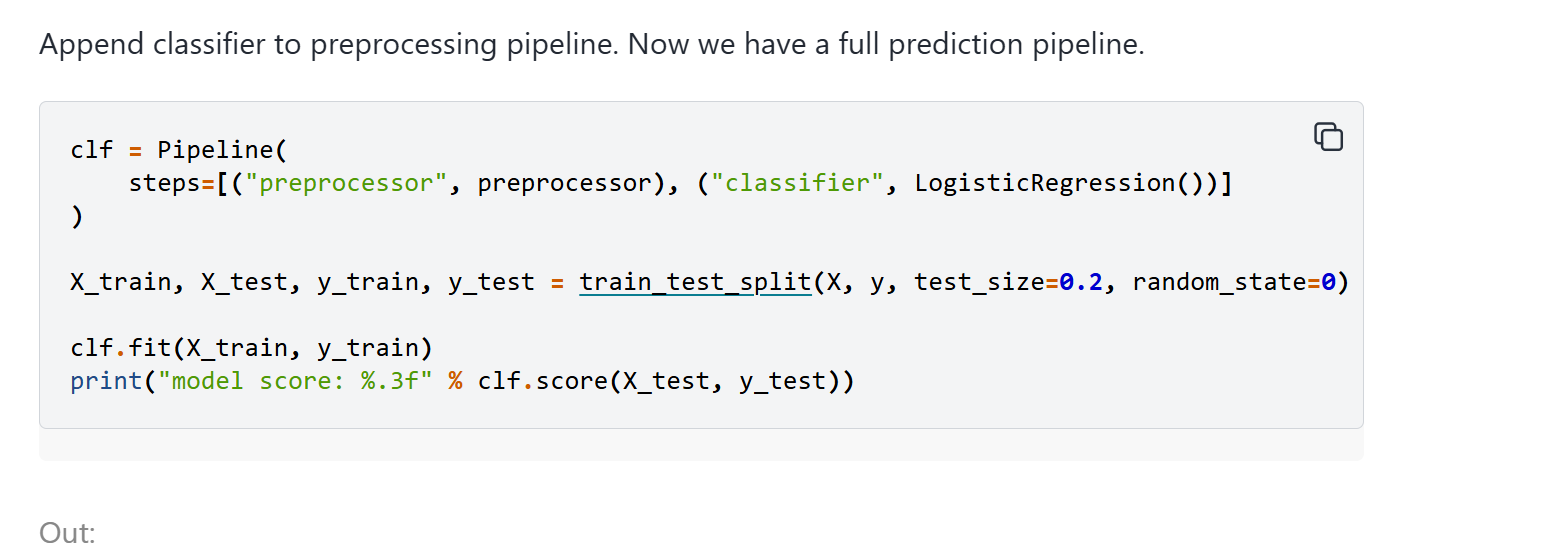
https://scikit-learn.org/1.5/auto_examples/compose/plot_column_transformer_mixed_types.html#sphx-glr-auto-examples-compose-plot-column-transformer-mixed-types-py

In [12]:
#--------------------------------------------------------------------------------
#Import Library
#--------------------------------------------------------------------------------
from sklearn.compose         import ColumnTransformer,make_column_transformer
from sklearn.preprocessing   import OneHotEncoder,LabelEncoder,MinMaxScaler,FunctionTransformer,QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline        import Pipeline,make_pipeline
#--------------------------------------------------------------------------------

### 3.1 Create Dependent (X) and Independent (y) Features<a id='1.1'></a>

In [13]:
# Function to separate input and output variables

def func_split_df_to_xy(data,target,train_or_test):
    
    #Input variable / feature
    if train_or_test == 'train':
        x = data.drop(target, axis = 1)
        y = data[target]
        
        return x,y
    else:
        x = data
    
    return x

### 3.2 Split X, y Features into Train and Valid Datasets<a id='3.2'></a>

In [14]:
# # Function to Typecast datatype into 'Category' Datatype

def func_split_into_train_valid(df,df_type,test_size=0.2,random_state=42):
    
    if df_type == 'train':
        X_features,y_target = func_split_df_to_xy(df,'Revenue','train')
        X_train,X_valid,y_train,y_valid=train_test_split(X_features,y_target,test_size=test_size,random_state=random_state)
        
        return X_train,X_valid,y_train,y_valid
    else:
        X_train = df
        
        return X_train

In [15]:
X_train,X_valid,y_train,y_valid = func_split_into_train_valid(online_shoppers_data_df,'train')
# X_train = func_split_into_train_valid(online_shoppers_data_df,'test')
print('X_train: ',X_train.shape,'X_valid: ',X_valid.shape)
print('y_train: ',y_train.shape,'y_valid: ',y_valid.shape)

X_train:  (9864, 17) X_valid:  (2466, 17)
y_train:  (9864,) y_valid:  (2466,)


In [17]:
#--------------------------------------------------------------------------------
# Create custom transformer using the 'FunctionTransformer'
#--------------------------------------------------------------------------------
kwargs_log_cols        = {'logging_cols':mnmx_cols}
#--------------------------------------------------------------------------------
fn_log_cols            = FunctionTransformer(func_log_cols,kw_args=kwargs_log_cols)
#--------------------------------------------------------------------------------
# Instantiate Scikit Transformers and FunctionTransformer using Pipeline
#--------------------------------------------------------------------------------
minmax_pipeline         = Pipeline(steps=[('mnx_transformer', MinMaxScaler())])
onehot_pipeline         = Pipeline(steps=[('ohe_transformer',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))])
#--------------------------------------------------------------------------------
# Build ColumnTransfomer
#--------------------------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('minmax_transformer'          ,minmax_pipeline,mnmx_cols),
        ('onehot_transformer'          ,onehot_pipeline,cat_cols_ohe)
    ],remainder='passthrough')
preprocessor.set_output(transform='pandas')  # Set output to pandas

ColumnTransformer(remainder='passthrough',
                  transformers=[('minmax_transformer',
                                 Pipeline(steps=[('mnx_transformer',
                                                  MinMaxScaler())]),
                                 ['Administrative_Duration',
                                  'Informational_Duration', 'ProductRelated',
                                  'Administrative', 'Informational',
                                  'ProductRelated_Duration', 'PageValues']),
                                ('onehot_transformer',
                                 Pipeline(steps=[('ohe_transformer',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Browser', 'Region', 'TrafficType',
                                  'OperatingSystems', 'Month',
                                  'VisitorType'])])

In [18]:
#--------------------------------------------------------------------------------
# Perform fit-transform, transform datasets
#-------------------------------------------------------------------------------
clf = Pipeline(steps=[('preprocessor', preprocessor)])
X_scaled_train = clf.fit_transform(X_train)
X_scaled_valid = clf.transform(X_valid)
X_scaled_train.reset_index(drop=True,inplace=True)
X_scaled_valid.reset_index(drop=True,inplace=True)

In [20]:
X_scaled_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 73 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   minmax_transformer__Administrative_Duration        9864 non-null   float64
 1   minmax_transformer__Informational_Duration         9864 non-null   float64
 2   minmax_transformer__ProductRelated                 9864 non-null   float64
 3   minmax_transformer__Administrative                 9864 non-null   float64
 4   minmax_transformer__Informational                  9864 non-null   float64
 5   minmax_transformer__ProductRelated_Duration        9864 non-null   float64
 6   minmax_transformer__PageValues                     9864 non-null   float64
 7   onehot_transformer__Browser_1                      9864 non-null   float64
 8   onehot_transformer__Browser_2                      9864 non-null   float64
 9   onehot_t

In [21]:
X_scaled_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 73 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   minmax_transformer__Administrative_Duration        2466 non-null   float64
 1   minmax_transformer__Informational_Duration         2466 non-null   float64
 2   minmax_transformer__ProductRelated                 2466 non-null   float64
 3   minmax_transformer__Administrative                 2466 non-null   float64
 4   minmax_transformer__Informational                  2466 non-null   float64
 5   minmax_transformer__ProductRelated_Duration        2466 non-null   float64
 6   minmax_transformer__PageValues                     2466 non-null   float64
 7   onehot_transformer__Browser_1                      2466 non-null   float64
 8   onehot_transformer__Browser_2                      2466 non-null   float64
 9   onehot_t

In [24]:
X_scaled_train.head()

,minmax_transformer__Administrative_Duration,minmax_transformer__Informational_Duration,minmax_transformer__ProductRelated,minmax_transformer__Administrative,minmax_transformer__Informational,minmax_transformer__ProductRelated_Duration,minmax_transformer__PageValues,onehot_transformer__Browser_1,onehot_transformer__Browser_2,onehot_transformer__Browser_3,...,onehot_transformer__Month_Nov,onehot_transformer__Month_Oct,onehot_transformer__Month_Sep,onehot_transformer__VisitorType_New_Visitor,onehot_transformer__VisitorType_Other,onehot_transformer__VisitorType_Returning_Visitor,remainder__BounceRates,remainder__ExitRates,remainder__SpecialDay,remainder__Weekend
0,0.016035,0.051974,0.019858,0.037037,0.083333,0.008074,0.051737,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.017647,0.043137,0.0,0
1,0.037955,0.000000,0.043972,0.074074,0.000000,0.013548,0.050064,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.011828,0.034101,0.0,0
2,0.000000,0.000000,0.327660,0.000000,0.000000,0.175794,0.000000,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.001747,0.010029,0.0,1
3,0.000000,0.000000,0.011348,0.000000,0.000000,0.005018,0.000000,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.050000,0.2,0
4,0.007944,0.000000,0.021277,0.037037,0.000000,0.023239,0.000000,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.013810,0.0,1


In [25]:
X_scaled_train['minmax_transformer__Administrative_Duration'].head()

0    0.016035
1    0.037955
2    0.000000
3    0.000000
4    0.007944
Name: minmax_transformer__Administrative_Duration, dtype: float64

In [26]:
(X_train.shape,X_scaled_train.shape,y_train.shape),(X_valid.shape,X_scaled_valid.shape,y_valid.shape)

(((9864, 17), (9864, 73), (9864,)), ((2466, 17), (2466, 73), (2466,)))

In [27]:
y_train.value_counts()

0    8322
1    1542
Name: Revenue, dtype: int64

In [28]:
y_train.dtypes

dtype('int64')

## 9. Build Model<a id='9'></a>

### 9.1 Import Libraries<a id='9.1'></a>

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

### 9.2 Handle the Imbalance<a id='9.2'></a>

In [30]:
# Handle imbalance using SMOTE (you can try other methods too)

# Apply SMOTE and check out the data labels: Before and Afte

print('The shape of X_scaled_train (Before SMOTE): {}'.format(X_scaled_train.shape))
print('The shape of y_train (Before SMOTE): {}'.format(y_train.shape))
print("\ny_train (Before SMOTE), counts of label '1': {}".format(sum(y_train==True)))
print("y_train (Before SMOTE), counts of label '0': {}".format(sum(y_train==False)))

The shape of X_scaled_train (Before SMOTE): (9864, 73)
The shape of y_train (Before SMOTE): (9864,)

y_train (Before SMOTE), counts of label '1': 1542
y_train (Before SMOTE), counts of label '0': 8322


In [31]:
# Apply SMOTE to the training data
sm = SMOTE(sampling_strategy='minority',random_state=0)
X_scaled_train_smote, y_train_smote = sm.fit_resample(X_scaled_train, y_train)

print('\nThe shape of X_scaled_train_smote(After SMOTE): {}'.format(X_scaled_train_smote.shape))
print('The shape of y_train_smote(After SMOTE): {}'.format(y_train_smote.shape))
print("y_train_resample(After SMOTE), counts of label '1': {}".format(sum(y_train_smote==True)))
print("y_train_resample(After SMOTE), counts of label '0': {}".format(sum(y_train_smote==False)))


The shape of X_scaled_train_smote(After SMOTE): (16644, 73)
The shape of y_train_smote(After SMOTE): (16644,)
y_train_resample(After SMOTE), counts of label '1': 8322
y_train_resample(After SMOTE), counts of label '0': 8322


### 9.3 Instantiate the Classifier and Define Parameter Grid<a id='9.3'></a>

In [32]:
# Define the SVM classifier
#-----------------------------------------------
svm_rbf = SVC()
svm_sig = SVC()
#-----------------------------------------------
# Define the parameter grid for GridSearchCV
#-----------------------------------------------
param_grid_rbf = {
    'C': [0.0001,0.001,0.01,0.5],
    'gamma': [0.0001, 0.001, 0.01, 0.5],
    'kernel': ['rbf']
}
param_grid_sig = {
    'C': [0.0001,0.01,0.1,0.5],
    'gamma': [0.001, 0.01, 0.1, 0.5],
    'kernel': ['sigmoid']
}

### 9.4 Perform GridSearchCV and Get 'Best_Estimator' and 'Best _Params'<a id='9.4'></a>

In [33]:
# Perform GridSearchCV with respective 'RBF', 'Sigmoid' and 'Poly' Kernal
#-------------------------------------------------------------------------------------------------
grid_search_rbf = GridSearchCV(svm_rbf, param_grid_rbf, cv=5, scoring='f1')
grid_search_sig = GridSearchCV(svm_sig, param_grid_sig, cv=5, scoring='f1')

In [34]:
grid_search_rbf.fit(X_scaled_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.0001, 0.001, 0.01, 0.5],
                         'gamma': [0.0001, 0.001, 0.01, 0.5],
                         'kernel': ['rbf']},
             scoring='f1')

In [35]:
import joblib

# Get the best parameters and estimator
best_estimator_rbf = grid_search_rbf.best_estimator_

# Save the model using joblib
joblib.dump(best_estimator_rbf, 'best_estimator_rbf.joblib')
# Save the model using joblib

['best_estimator_rbf.joblib']

In [36]:
grid_search_sig.fit(X_scaled_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.0001, 0.01, 0.1, 0.5],
                         'gamma': [0.001, 0.01, 0.1, 0.5],
                         'kernel': ['sigmoid']},
             scoring='f1')

In [37]:
best_estimator_sig = grid_search_sig.best_estimator_
joblib.dump(best_estimator_sig, 'best_estimator_sig.joblib')

['best_estimator_sig.joblib']

In [38]:
# Load the model
# best_estimator_rbf = joblib.load('best_estimator_rbf.joblib')
# Load the model
# best_estimator_sig = joblib.load('best_estimator_sig.joblib')

In [39]:
best_params_rbf = grid_search_rbf.best_params_
best_params_sig = grid_search_sig.best_params_

In [40]:
#-------------------------------------------------------------------------------------------------
# Make predictions using the "best estimator" and get the probabilities for Positive Class
#-------------------------------------------------------------------------------------------------
y_train_best_pred_rbf = best_estimator_rbf.predict(X_scaled_train_smote)
y_valid_best_pred_rbf = best_estimator_rbf.predict(X_scaled_valid)
#
y_train_best_pred_sig = best_estimator_sig.predict(X_scaled_train_smote)
y_valid_best_pred_sig = best_estimator_sig.predict(X_scaled_valid)

### 9.5 Compute Model Metrices<a id='9.5'></a>

In [41]:
#-------------------------------------------------------------------------------------------------
#Compute 'Precision, Recall, F1-Score' for ''y and y_valid' Using 'best_estimator'
#-------------------------------------------------------------------------------------------------
from sklearn.metrics import confusion_matrix, f1_score, mean_squared_error, classification_report, accuracy_score, \
recall_score, log_loss, precision_score, roc_auc_score, roc_curve, precision_recall_curve, \
auc, cohen_kappa_score, balanced_accuracy_score,average_precision_score
#--------------------------------------------------------------------------------------------------
kernals=[];precision_trains=[];recall_trains=[];f1_trains=[];precision_valids=[];recall_valids=[];f1_valids=[]
#--------------------------------------------------------------------------------------------------
precision_train_rbf = precision_score(y_train_smote, y_train_best_pred_rbf)
recall_train_rbf    = recall_score(y_train_smote,    y_train_best_pred_rbf)
f1_train_rbf        = f1_score(y_train_smote,        y_train_best_pred_rbf)
#-------------------------------------------------------------------------
precision_valid_rbf = precision_score(y_valid,       y_valid_best_pred_rbf)
recall_valid_rbf    = recall_score(y_valid,          y_valid_best_pred_rbf)
f1_valid_rbf        = f1_score(y_valid,              y_valid_best_pred_rbf)
#-------------------------------------------------------------------------
kernals.append('SVM-RBF');
precision_trains.append(precision_train_rbf);recall_trains.append(recall_train_rbf);f1_trains.append(f1_train_rbf)
precision_valids.append(precision_valid_rbf);recall_valids.append(recall_valid_rbf);f1_valids.append(f1_valid_rbf)
# #---------------------------------------------------------------------------------------------------------
# #---------------------------------------------------------------------------------------------------------
precision_train_sig = precision_score(y_train_smote, y_train_best_pred_sig)
recall_train_sig    = recall_score(y_train_smote,    y_train_best_pred_sig)
f1_train_sig        = f1_score(y_train_smote,        y_train_best_pred_sig)
#-------------------------------------------------------------------------
precision_valid_sig = precision_score(y_valid,       y_valid_best_pred_sig)
recall_valid_sig    = recall_score(y_valid,          y_valid_best_pred_sig)
f1_valid_sig        = f1_score(y_valid,              y_valid_best_pred_sig)
#-------------------------------------------------------------------------
kernals.append('SVM-SIGMOID');
precision_trains.append(precision_train_sig);recall_trains.append(recall_train_sig);f1_trains.append(f1_train_sig)
precision_valids.append(precision_valid_sig);recall_valids.append(recall_valid_sig);f1_valids.append(f1_valid_sig)
#---------------------------------------------------------------------------------------------------------
#----------------------------------------------------------------------------------------------------------

In [42]:
len(kernals),len(precision_trains),len(recall_trains),len(f1_trains),len(precision_valids),len(recall_valids),len(f1_valids)

(2, 2, 2, 2, 2, 2, 2)

### 9.6 List and Visualize the Model Performance<a id='9.6'></a>

In [43]:

svm_scores   = ({
    'Kernal':kernals,
    'F1_Train':f1_trains,'Precision_Train':precision_trains,'Recall_Train':recall_trains,
    'F1_Valid':f1_valids,'Precision_Valid':precision_valids,'Recall_Valid':recall_valids
})
svm_scores_df = pd.DataFrame(svm_scores)
svm_scores_df.set_index('Kernal',drop=True,inplace=True)
svm_scores_df.head()

,F1_Train,Precision_Train,Recall_Train,F1_Valid,Precision_Valid,Recall_Valid
Kernal,,,,,,
SVM-RBF,0.880723,0.855718,0.907234,0.331528,0.274686,0.418033
SVM-SIGMOID,0.713011,0.715513,0.710526,0.378947,0.269275,0.639344


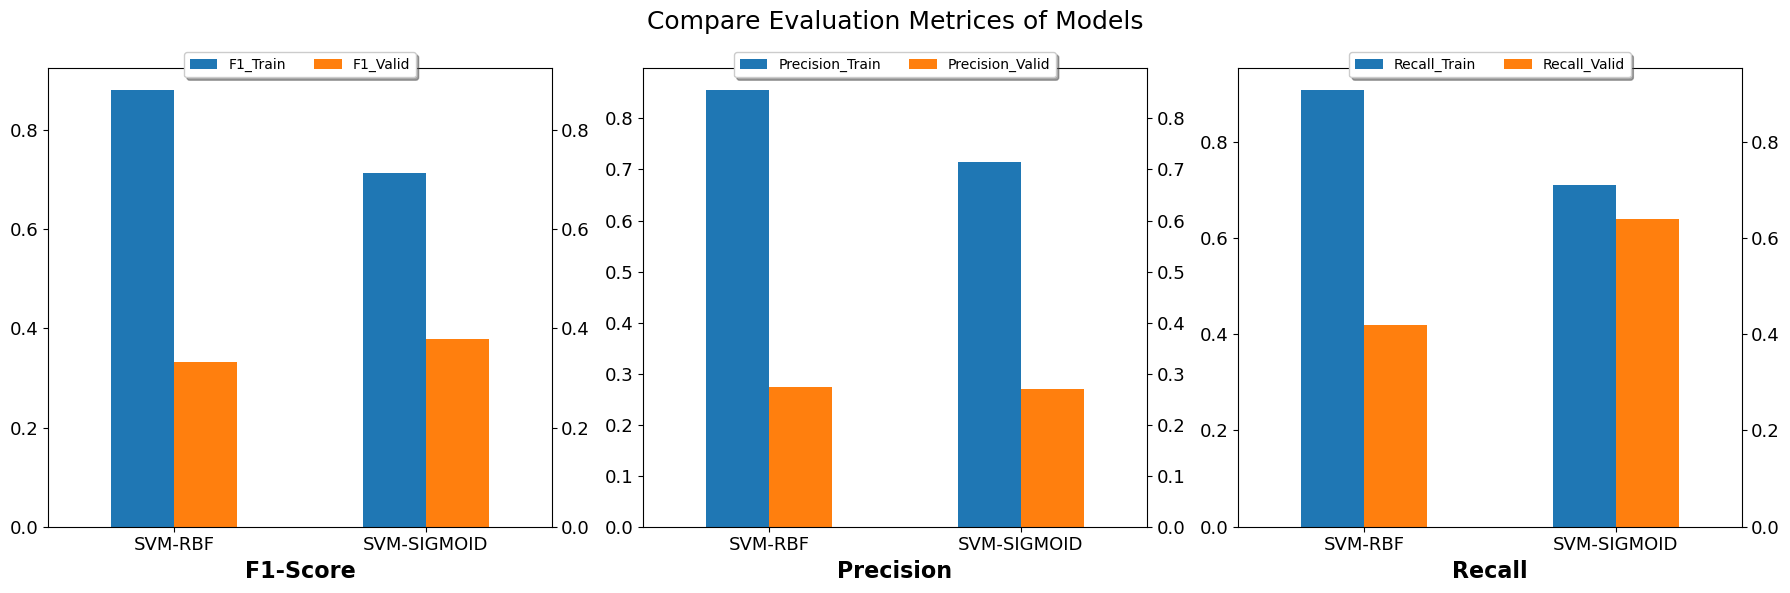

In [44]:
fig,ax = plt.subplots(figsize=(18,6), nrows=1,ncols=3)
plt.suptitle("Compare Evaluation Metrices of Models", fontsize=18)

svm_scores_df.plot(y=['F1_Train','F1_Valid'],kind='bar',ax=ax[0]);
ax[0].set_xlabel('F1-Score',fontsize=16,weight='bold')
ax[0].tick_params(labelbottom=True, labelright=True,bottom=True,right=True,labelrotation=0,labelsize=13)
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),ncols=4,fancybox=True, shadow=True)

svm_scores_df.plot(y=['Precision_Train','Precision_Valid'],kind='bar',ax=ax[1]);
ax[1].set_xlabel('Precision',fontsize=16,weight='bold')
ax[1].tick_params(labelbottom=True, labelright=True,bottom=True,right=True,labelrotation=0,labelsize=13)
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),ncols=4,fancybox=True, shadow=True)

svm_scores_df.plot(y=['Recall_Train','Recall_Valid'],kind='bar',ax=ax[2]);
ax[2].set_xlabel('Recall',fontsize=16,weight='bold')
ax[2].tick_params(labelbottom=True, labelright=True,bottom=True,right=True,labelrotation=0,labelsize=13)
ax[2].legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),ncols=4,fancybox=True, shadow=True)

plt.tight_layout()
plt.show()